Подгружаем необходимые библиотеки для анализа данных, обучения модели и предсказания

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

Загружаем данные для обучения модели и предсказания         

In [2]:
df_train = pd.read_csv('/kaggle/input/mai-ml-contest-1/train.csv').dropna().select_dtypes(include=[np.number])
df_test = pd.read_csv('/kaggle/input/mai-ml-contest-1/test.csv').dropna().select_dtypes(include=[np.number])
# pd.set_option('display.float_format', str)

Фильтруем (убираем выбросы и находим аномалии) и анализируем данные

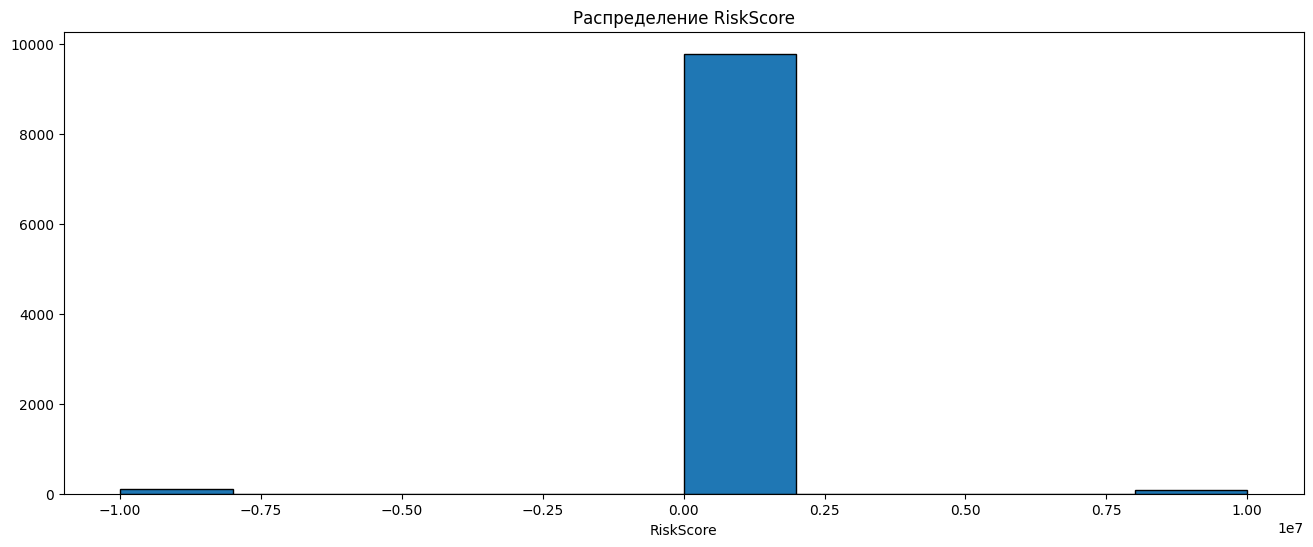

In [3]:
data = df_train['RiskScore']
plt.figure(figsize=(16,6))
plt.hist(data, ec='k')
plt.title('Распределение RiskScore')
plt.xlabel('RiskScore')
plt.show()

Видим, что значения RiskScore больше 100 и меньше 0 являются выбросами, убираем их. Продолжаем исследование.

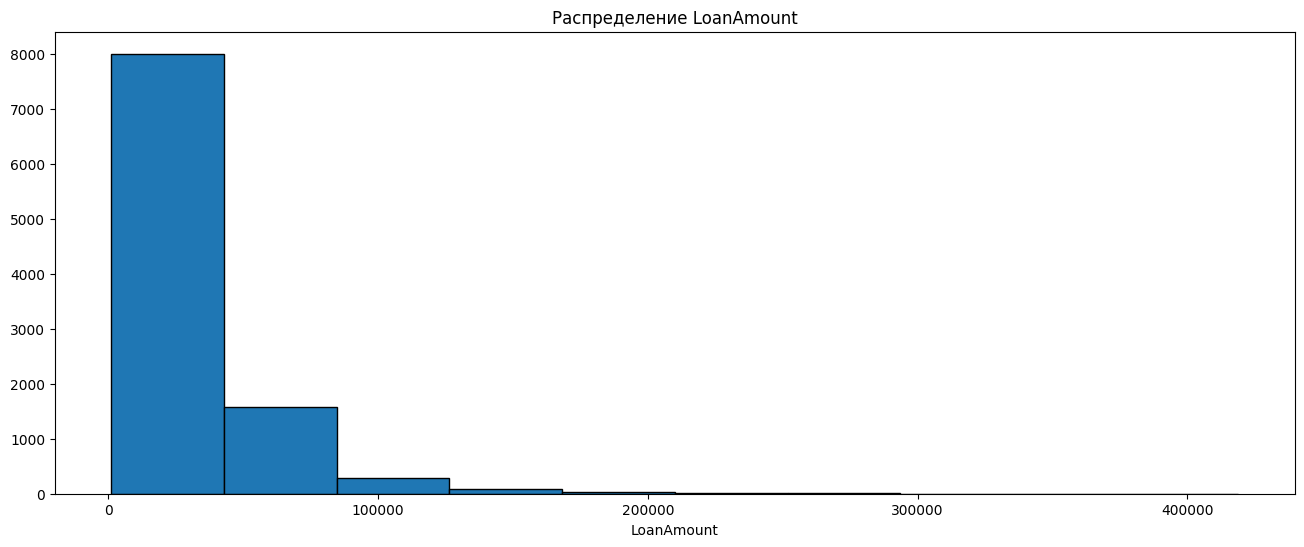

In [4]:
data = df_train['LoanAmount']
plt.figure(figsize=(16,6))
plt.hist(data, ec='k')
plt.title('Распределение LoanAmount')
plt.xlabel('LoanAmount')
plt.show()

Для LoanAmount (запрашиваемая сумма кредита) редко встречаются значения выше 200000, отсекаем их.

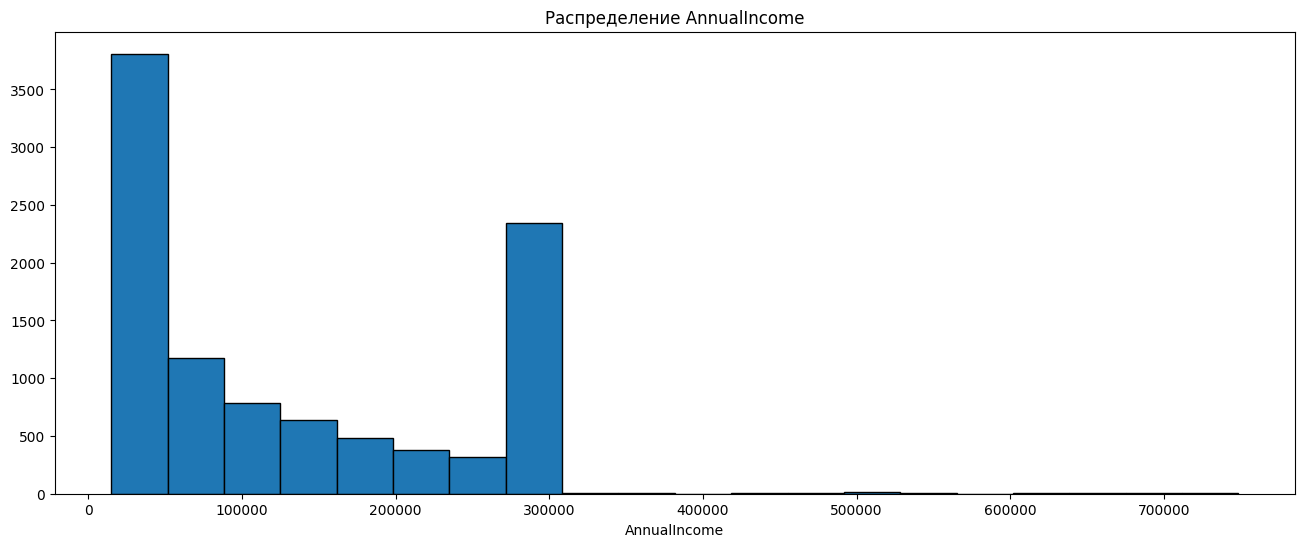

In [5]:
data = df_train['AnnualIncome']
plt.figure(figsize=(16,6))
plt.hist(data, ec='k', bins=20)
plt.title('Распределение AnnualIncome')
plt.xlabel('AnnualIncome')
plt.show()

В случае AnnualIncome проявляются иногда значения выше 400000, но довольно редко. Уберём их из обучающей выборки.

Применим фильтрацию

In [6]:
df_train = df_train[(df_train['RiskScore'] < 100) &
                    (df_train['RiskScore'] > 0) &
                    (df_train['LoanAmount'] < 200000) &
                    (df_train['AnnualIncome'] < 400000)]

Разделим датасет для обучения на переменные и истинное значение наблюдения

In [7]:
X_train = df_train.loc[:, df_train.columns != 'RiskScore']
y_train = df_train['RiskScore']

# X_train, X_test, y_train, y_test = train_test_split(df_train.loc[:, df_train.columns != 'RiskScore'], df_train['RiskScore'], train_size=0.8)

Обучим модель на тренировочной выборке

In [8]:
sk_reg = LinearRegression()
sk_reg.fit(X_train, y_train)
# y_pred = sk_reg.predict(X_test)
# mse = ((y_test - y_pred) ** 2).mean()
# print(mse)

LinearRegression()

Предскажем с помощью полученной модели значения для тестовой выборки и запишем их в CSV файл

In [9]:
X_test = df_test.drop(columns=['ID'], errors='ignore')
y_pred = sk_reg.predict(X_test)
submission = pd.DataFrame({
    'ID': df_test['ID'],
    'RiskScore': y_pred
})

submission.to_csv('/kaggle/working/solution.csv', index=False)